**Geração de pontos 2D usando umadistribuição Gaussiana multivariada**

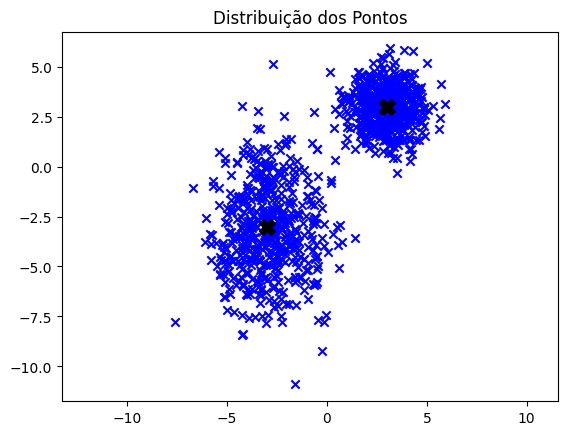

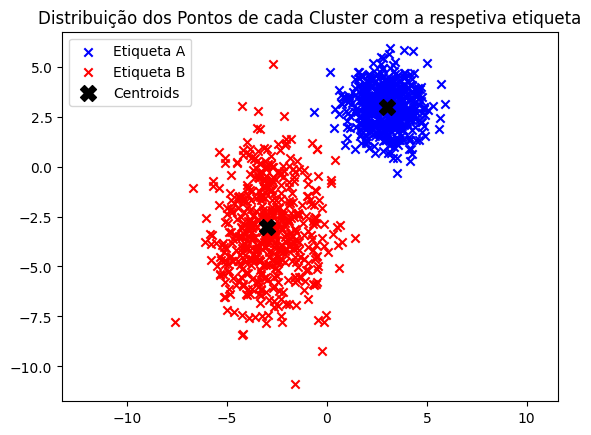

In [136]:
import matplotlib.pyplot as plt
import numpy as np
import random

centroids = np.array([[3,3], [-3,-3]])
mean = [3, 3]
cov = [[1 , 0], [0, 1]]
a = np.random.multivariate_normal(mean, cov, 500).T
mean = [-3, -3]
cov = [[2 , 0], [0, 5]]
b = np.random.multivariate_normal(mean, cov, 500).T
c = np.concatenate((a, b) , axis = 1)
c = c.T
etiqueta_a = np.ones((a.shape[1], 1))
etiqueta_b = np.full((b.shape[1], 1), 2)
etiquetas = np.vstack((etiqueta_a, etiqueta_b))
c = np.hstack((c, etiquetas))
np.random. shuffle(c)
c = c.T
x = c[0]
y = c[1]
etiquetas = c[2]


plt.scatter(x, y, c='blue', marker='x')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis ( 'equal' )
plt.title('Distribuição dos Pontos')
plt.show()


plt.scatter(x[etiquetas == 1], y[etiquetas == 1], c='blue', marker='x', label='Etiqueta A')
plt.scatter(x[etiquetas == 2], y[etiquetas == 2], c='red', marker='x', label='Etiqueta B')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis('equal')
plt.legend()
plt.title('Distribuição dos Pontos de cada Cluster com a respetiva etiqueta')
plt.show()

np.savetxt('conjunto_de_etiquetas.txt', c.T, fmt='%.3f', delimiter=',', header='x,y,etiqueta', comments='')

**Implementação do algoritmo K-Means (1.2)**

Época 0 - r1: [2.618;3.922], r2: [-0.252;-3.594]
Época 1 - r1: [2.715748006049547;3.529807025068803], r2: [-1.2934566454818768;-3.4653522312249363]
Época 2 - r1: [2.7827422892676523;3.2957425968027634], r2: [-1.9329890397029679;-3.3783867645439076]
Época 3 - r1: [2.8289769773517146;3.1551719626248085], r2: [-2.3246173299371997;-3.3194777376609133]
Época 4 - r1: [2.8568449242556806;3.0704430473479105], r2: [-2.5635223305504113;-3.283541464785458]
Época 5 - r1: [2.8736423224176497;3.0193727144438762], r2: [-2.709261544854516;-3.2616192607275964]
Época 6 - r1: [2.883766950040347;2.988590083810574], r2: [-2.7981668357921747;-3.248246058881643]
Época 7 - r1: [2.889869566856935;2.9700358607455506], r2: [-2.8524017292246047;-3.2400880047397993]
Época 8 - r1: [2.8935479176465173;2.9588523073433923], r2: [-2.885486640534215;-3.235111347081611]
Época 9 - r1: [2.895765042682853;2.952111423272918], r2: [-2.905669428534495;-3.2320754366774587]
Época 10 - r1: [2.897101414254768;2.9480483570525897], 

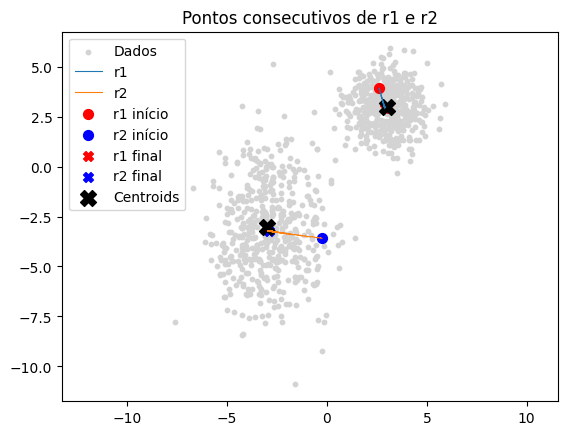

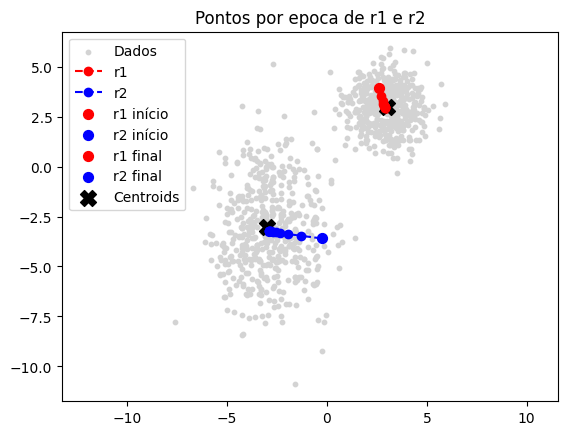

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.001
num_epocas = 10

r1_update = []
r2_update = []
r1_final = []
r2_final = []

r1_final.append(r1.copy())
r2_final.append(r2.copy())
print(f"Época 0 - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")


for epoca in range(1, num_epocas + 1):
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            r1 = (1-alpha) * r1 + alpha * x
            r1_update.append(r1.copy())
        else:
            r2 = (1-alpha) * r2 + alpha * x
            r2_update.append(r2.copy())
    r1_final.append(r1.copy())
    r2_final.append(r2.copy())
    print(f"Época {epoca} - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")

r1_update = np.array(r1_update)
r2_update = np.array(r2_update)
r1_final = np.array(r1_final)
r2_final = np.array(r2_final)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', s=10, label='Dados')
plt.plot(r1_update[:,0], r1_update[:,1], linewidth= 0.8, label='r1')
plt.plot(r2_update[:,0], r2_update[:,1], linewidth= 0.8, label='r2')
plt.scatter(r1_update[0,0], r1_update[0,1], c='red', marker='o', s=50, label='r1 início')
plt.scatter(r2_update[0,0], r2_update[0,1], c='blue', marker='o', s=50, label='r2 início')
plt.scatter(r1_update[-1,0], r1_update[-1,1], c='red', marker='X', s=50, label='r1 final')
plt.scatter(r2_update[-1,0], r2_update[-1,1], c='blue', marker='X', s=50, label='r2 final')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos consecutivos de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', s=10, label='Dados')
plt.plot(r1_final[:,0], r1_final[:,1], 'ro--', label='r1')
plt.plot(r2_final[:,0], r2_final[:,1], 'bo--', label='r2')
plt.scatter(r1_final[0,0], r1_final[0,1], c='red', marker='o', s=50, label='r1 início')
plt.scatter(r2_final[0,0], r2_final[0,1], c='blue', marker='o', s=50, label='r2 início')
plt.scatter(r1_final[-1,0], r1_final[-1,1], c='red', marker='o', s=50, label='r1 final')
plt.scatter(r2_final[-1,0], r2_final[-1,1], c='blue', marker='o', s=50, label='r2 final')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos por epoca de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()
    


**Kmeans - pontos acumulados**

Época 0 - r1: [1.8;3.521], r2: [0.582;2.654]
Época 1 - r1: [1.9297975824175824;3.4740806593406592], r2: [0.2672385321100916;2.1162302752293582]
Época 2 - r1: [2.0413875683422957;3.430488355249006], r2: [-0.02747471005712354;1.6169918194564654]
Época 3 - r1: [2.1384962933310065;3.389009891523534], r2: [-0.3018080626949675;1.157118454817072]
Época 4 - r1: [2.2234688513789553;3.349636920753905], r2: [-0.5554759468486989;0.7356993918118454]
Época 5 - r1: [2.298623883012594;3.3125120215774526], r2: [-0.7882790391098466;0.3519997489531533]
Época 6 - r1: [2.366278625052025;3.2790920971568687], r2: [-0.9978478306611366;0.006594240411386065]
Época 7 - r1: [2.4253353256504546;3.2487098677424204], r2: [-1.18817176485758;-0.3076718249338455]
Época 8 - r1: [2.477254365294958;3.2211039530859624], r2: [-1.3606009300414543;-0.5927588683536213]
Época 9 - r1: [2.523584379638521;3.1958763785679833], r2: [-1.5165855572233171;-0.8502437332919301]
Época 10 - r1: [2.565290658550597;3.1731665159868987], r2: [

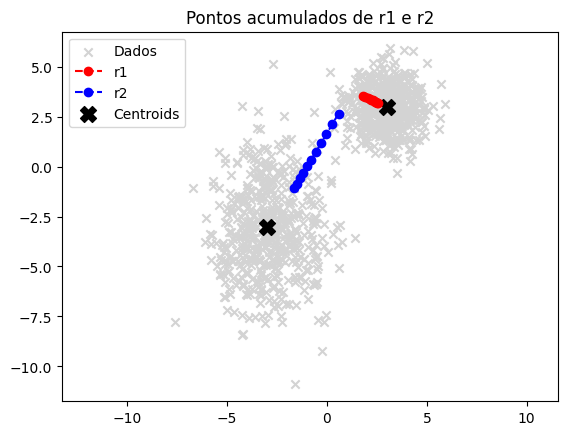

In [138]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.1
num_epocas = 10


r1_acc = []
r2_acc = []

r1_acc.append(r1.copy())
r2_acc.append(r2.copy())
print(f"Época 0 - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")

for epoca in range(1, num_epocas + 1):
    d1_total = np.zeros(2)
    d2_total = np.zeros(2)
    n1 = 0
    n2 = 0
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            d1_total += (x - r1)
            n1 += 1
        else:
            d2_total += (x - r2)
            n2 += 1

    if n1 > 0:
        r1 += alpha * (d1_total / n1)
    if n2 > 0:
        r2 += alpha * (d2_total / n2)       
    
    r1_acc.append(r1.copy())
    r2_acc.append(r2.copy())
    print(f"Época {epoca} - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")


r1_acc = np.array(r1_acc)
r2_acc = np.array(r2_acc)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_acc[:,0], r1_acc[:,1], 'ro--', label='r1')
plt.plot(r2_acc[:,0], r2_acc[:,1], 'bo--', label='r2')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos acumulados de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()


**Gráfico de cores consoante as etiquetas e a proximidade aos pontos r1 e r2**

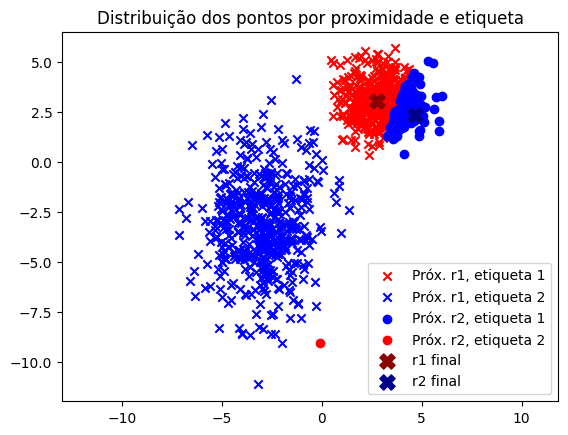

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]
etiquetas = pontos[:, 2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

dist_r1 = np.sqrt(np.sum((coordenadas-r1) ** 2, axis=1))
dist_r2 = np.sqrt(np.sum((coordenadas-r2) ** 2, axis=1))
prox_r1 = dist_r1 < dist_r2  


r1_etiqueta1 = (prox_r1) & (etiquetas == 1)
r1_etiqueta2 = (prox_r1) & (etiquetas == 2)
r2_etiqueta1 = (~prox_r1) & (etiquetas == 1)
r2_etiqueta2 = (~prox_r1) & (etiquetas == 2)


plt.scatter(coordenadas[r1_etiqueta1,0], coordenadas[r1_etiqueta1,1], c='red', marker='x', label='Próx. r1, etiqueta 1')
plt.scatter(coordenadas[r1_etiqueta2,0], coordenadas[r1_etiqueta2,1], c='blue', marker='x', label='Próx. r1, etiqueta 2')
plt.scatter(coordenadas[r2_etiqueta1,0], coordenadas[r2_etiqueta1,1], c='blue', marker='o', label='Próx. r2, etiqueta 1')
plt.scatter(coordenadas[r2_etiqueta2,0], coordenadas[r2_etiqueta2,1], c='red', marker='o', label='Próx. r2, etiqueta 2')

plt.scatter(r1[0], r1[1], c='darkred', s=120, marker='X', label='r1 final')
plt.scatter(r2[0], r2[1], c='darkblue', s=120, marker='X', label='r2 final')

plt.title("Distribuição dos pontos por proximidade e etiqueta")
plt.legend()
plt.axis('equal')
plt.show()

**Experiência de 30 tentativas**

Repetição 01 - r1 final: [-3.462, -2.680], r2 final: [0.905, 3.703]
Repetição 02 - r1 final: [3.228, 2.585], r2 final: [-2.202, -2.659]
Repetição 03 - r1 final: [-2.885, -2.853], r2 final: [2.929, 2.678]
Repetição 04 - r1 final: [2.937, 3.020], r2 final: [-0.937, -0.705]
Repetição 05 - r1 final: [0.486, 0.380], r2 final: [-3.573, -3.927]
Repetição 06 - r1 final: [2.649, 2.696], r2 final: [-2.325, -4.200]
Repetição 07 - r1 final: [-2.586, -2.998], r2 final: [3.361, 3.541]
Repetição 08 - r1 final: [-2.750, -5.075], r2 final: [2.196, 2.983]
Repetição 09 - r1 final: [-0.770, -1.681], r2 final: [2.632, 3.159]
Repetição 10 - r1 final: [3.275, 3.483], r2 final: [-2.807, -3.233]
Repetição 11 - r1 final: [3.374, 2.561], r2 final: [-3.207, -3.050]
Repetição 12 - r1 final: [0.119, 0.562], r2 final: [-3.494, -3.553]
Repetição 13 - r1 final: [-1.966, -6.541], r2 final: [-0.685, 1.021]
Repetição 14 - r1 final: [-0.385, -1.190], r2 final: [-4.372, -5.630]
Repetição 15 - r1 final: [2.239, 2.707], r2 f

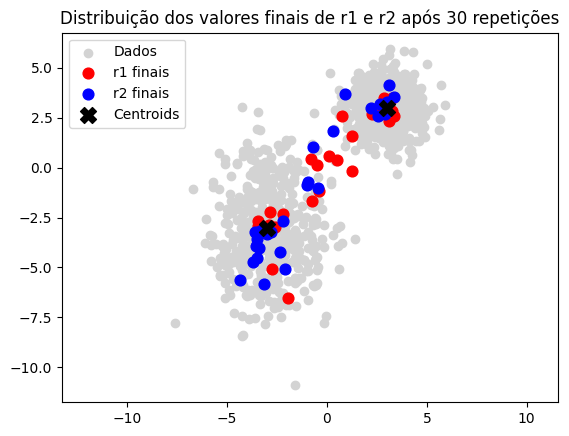

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


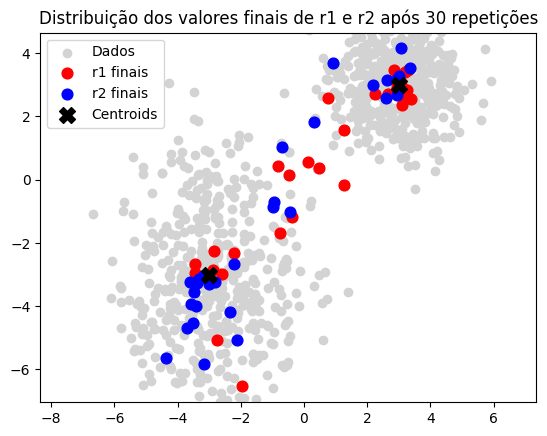

In [139]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas = pontos[:, 0:2]

alpha = 0.1
num_epocas = 10
num_repeticoes = 30

r1_finais = []
r2_finais = []

for repeticao in range(1, num_repeticoes + 1):
    r1 = coordenadas[random.randint(0, len(coordenadas)-1)]
    r2 = coordenadas[random.randint(0, len(coordenadas)-1)]

    for epoca in range(num_epocas):
        d1_total = np.zeros(2)
        d2_total = np.zeros(2)
        n1 = 0
        n2 = 0

        for x in coordenadas:
            d1 = np.sqrt(np.sum((x - r1) ** 2))
            d2 = np.sqrt(np.sum((x - r2) ** 2))

            if d1 < d2:
                d1_total += (x - r1)
                n1 += 1
            else:
                d2_total += (x - r2)
                n2 += 1

        if n1 > 0:
            r1 += alpha * (d1_total / n1)
        if n2 > 0:
            r2 += alpha * (d2_total / n2)

    r1_finais.append(r1.copy())
    r2_finais.append(r2.copy())

    print(f"Repetição {repeticao:02d} - r1 final: [{r1[0]:.3f}, {r1[1]:.3f}], r2 final: [{r2[0]:.3f}, {r2[1]:.3f}]")


r1_finais = np.array(r1_finais)
r2_finais = np.array(r2_finais)



plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
todos = np.vstack((r1_finais, r2_finais))
plt.xlim(todos[:,0].min()-0.5, todos[:,0].max()+0.5)
plt.ylim(todos[:,1].min()-0.5, todos[:,1].max()+0.5)
plt.show()

**Exercicio 2 - Clustering aglomerativo hierárquico**

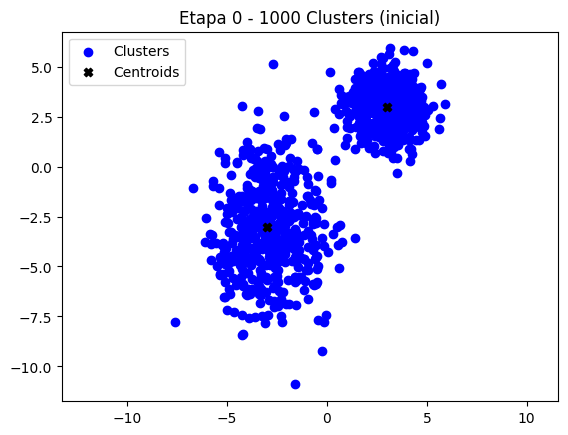

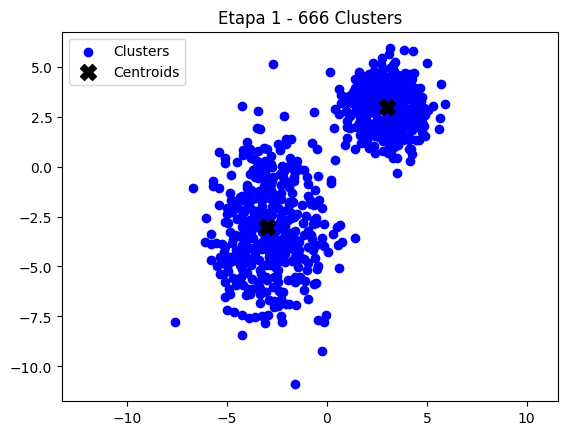

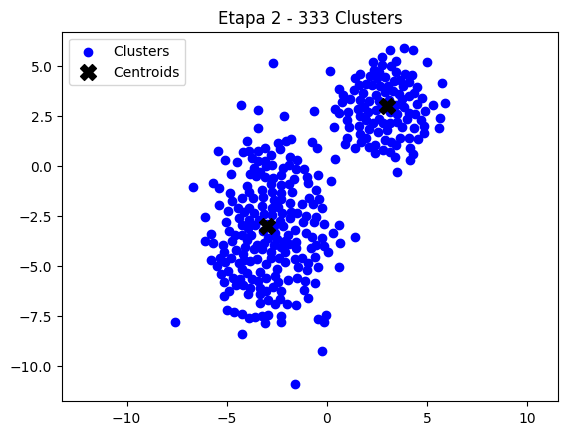

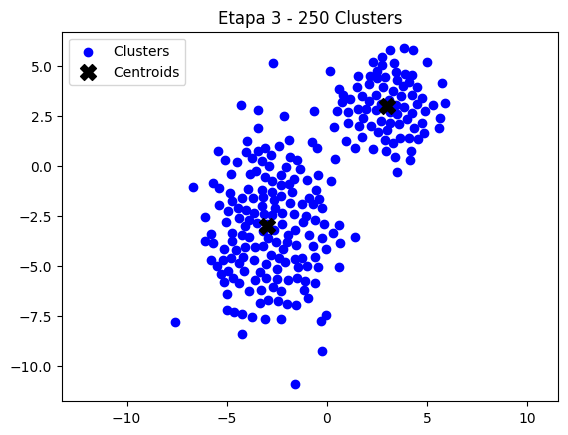

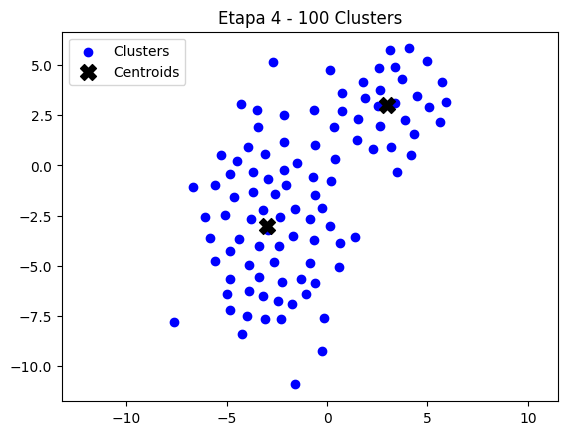

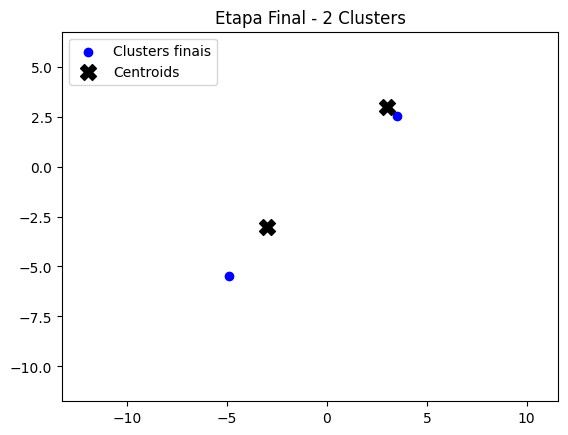

In [140]:
import numpy as np
import matplotlib.pyplot as plt


pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
pontos_iniciais = pontos.copy() 
n_inicial = len(pontos)


marcos = [int(2*n_inicial/3), int(n_inicial/3), 250, 100]

centroids = np.array([[3,3], [-3,-3]])


plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
plt.axis('equal')
plt.title(f"Etapa 0 - {n_inicial} Clusters (inicial)")
plt.legend()
plt.show()


while len(pontos) > 2:
    min_dist = float('inf')
    p1, p2 = None, None
    for i in range(len(pontos)):
        for j in range(i+1, len(pontos)):
            d = np.sqrt(np.sum((pontos[i]-pontos[j])**2))
            if d < min_dist:
                min_dist = d
                p1, p2 = i, j

    novo_ponto = (pontos[p1] + pontos[p2])/2
    pontos = np.delete(pontos, [p1,p2], axis=0)
    pontos = np.vstack([pontos, novo_ponto])

    if len(pontos) in marcos:
        idx = marcos.index(len(pontos))
        plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
        plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
        plt.axis('equal')
        plt.title(f"Etapa {idx+1} - {len(pontos)} Clusters")
        plt.legend()
        plt.show()


plt.scatter(pontos_iniciais[:,0], pontos_iniciais[:,1], c='white', alpha=0)
plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis('equal')
plt.title("Etapa Final - 2 Clusters")
plt.legend()
plt.show()

**Exercicio 3 - Algoritmo DBSCAN** 

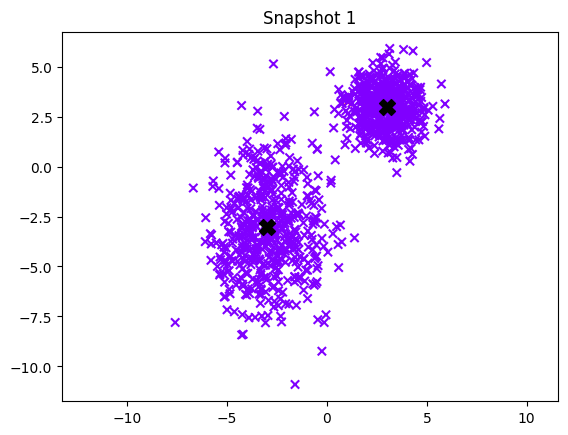

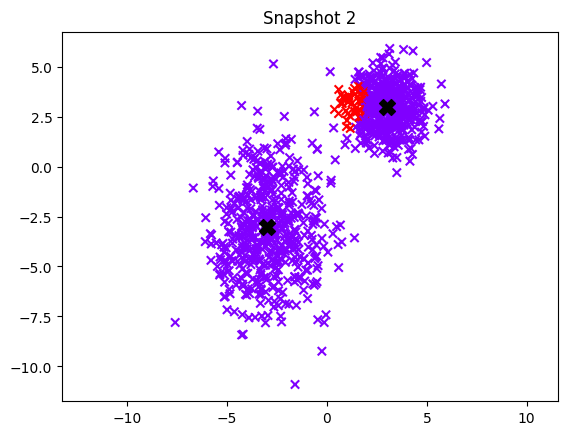

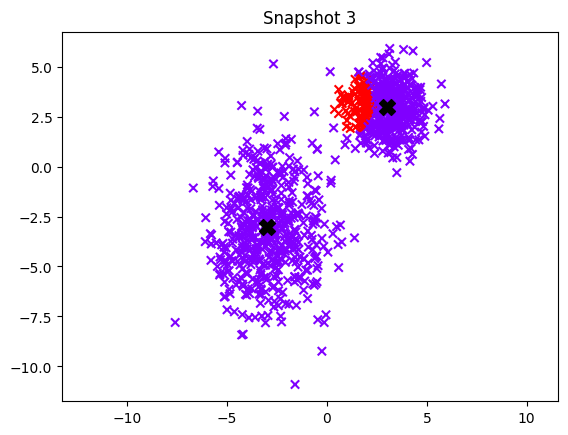

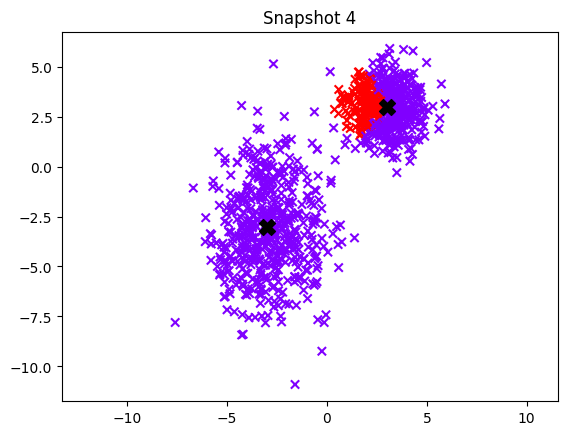

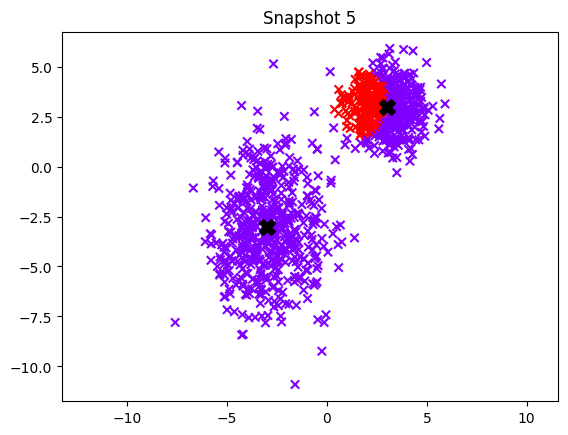

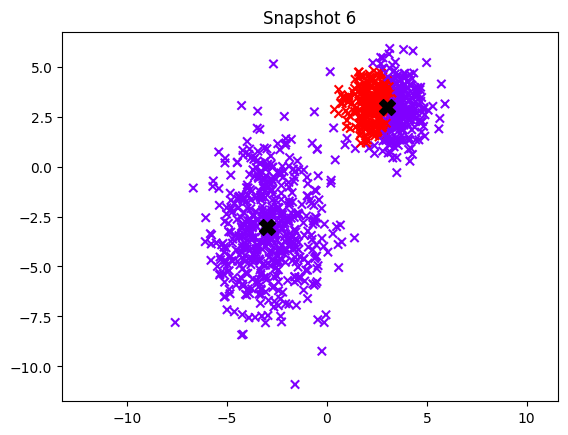

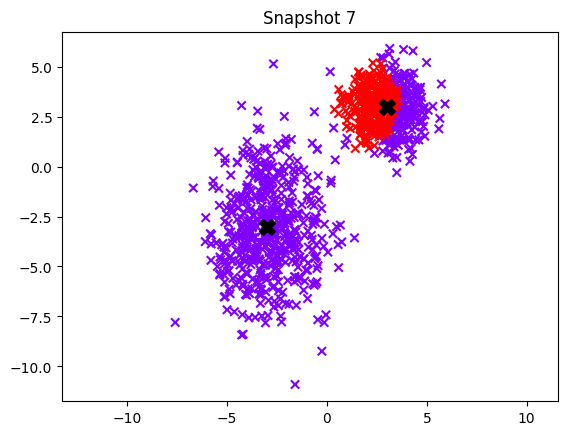

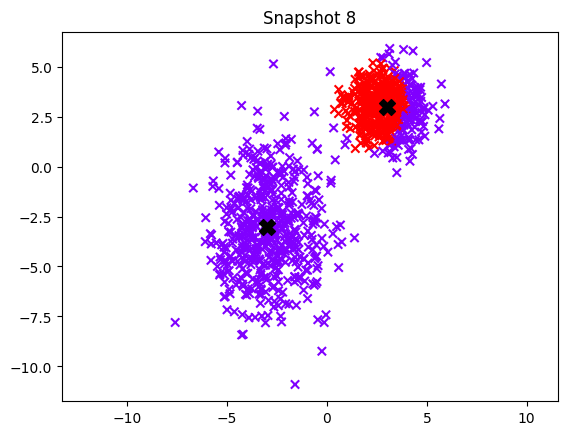

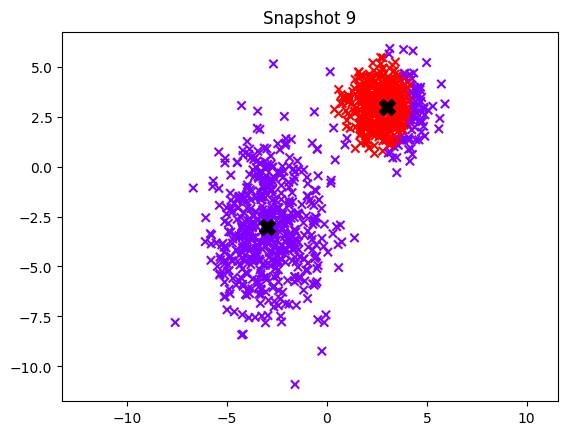

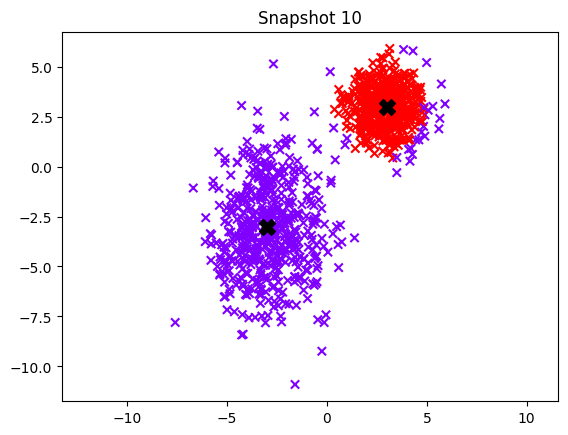

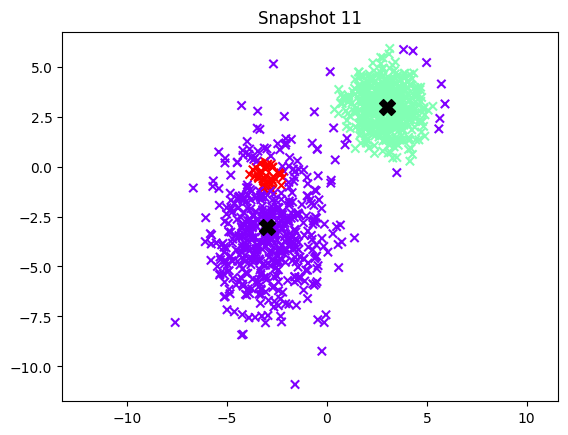

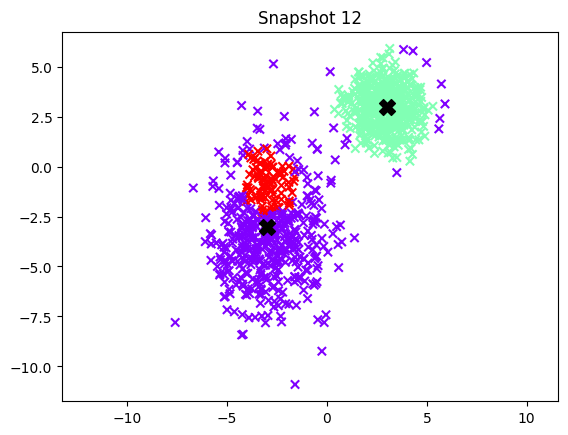

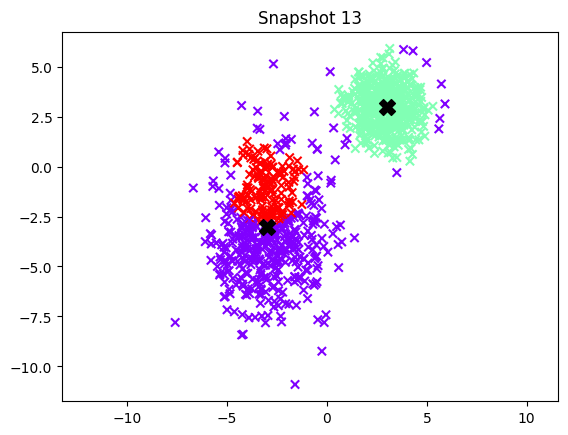

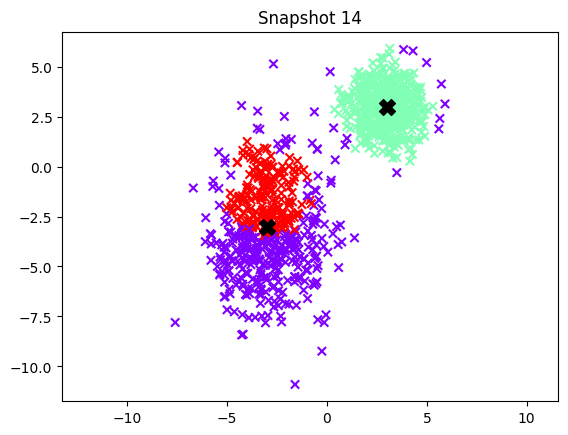

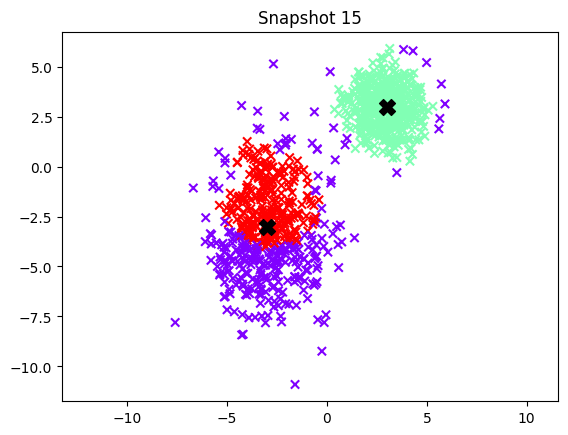

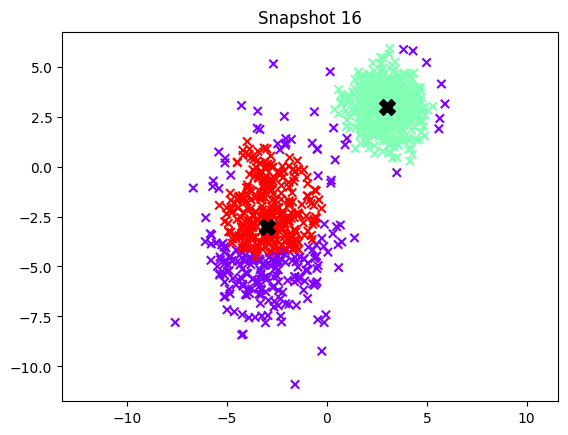

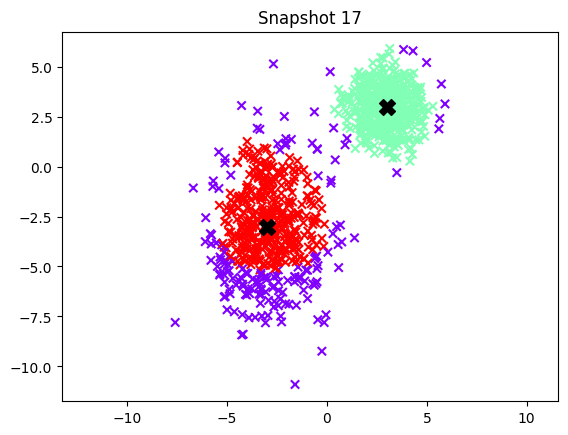

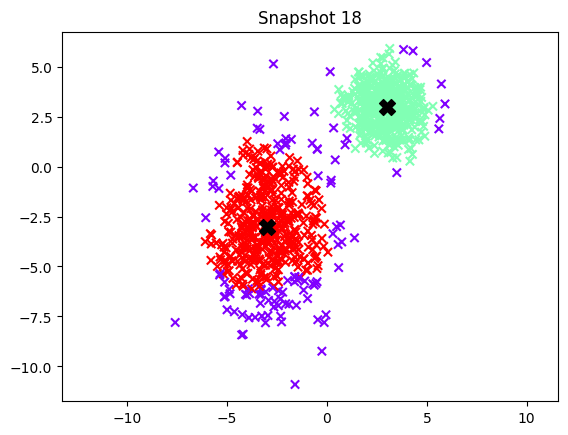

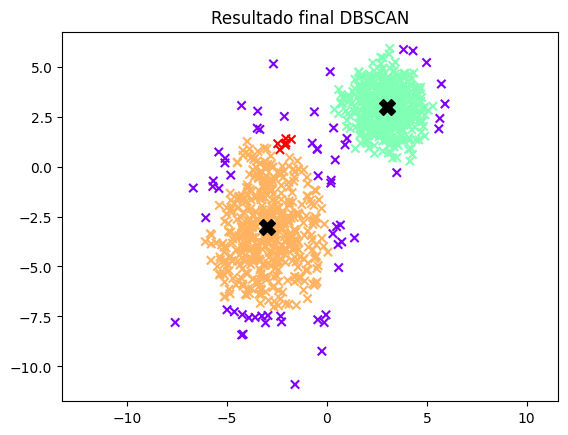

In [146]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
n_points = len(data)

eps = 0.5
min_samples = 5
labels = np.zeros(n_points, dtype=int)  
cluster_id = 1

num_snapshots = 20
snapshot_indices = np.linspace(0, n_points-1, num_snapshots, dtype=int)
snapshots = []
step_counter = 0 


x_min, x_max = np.min(data[:, 0]), np.max(data[:, 0])
y_min, y_max = np.min(data[:, 1]), np.max(data[:, 1])
for i in range(n_points):
    if labels[i] != 0:
        continue

    neighbors = []
    for j in range(n_points):
        if np.sqrt(np.sum((data[i] - data[j]) ** 2)) <= eps:
            neighbors.append(j)

    if len(neighbors) < min_samples:
        labels[i] = -1  
    else:
        labels[i] = cluster_id
        k = 0
        while k < len(neighbors):
            idx = neighbors[k]
            if labels[idx] == -1:
                labels[idx] = cluster_id
            elif labels[idx] == 0:
                labels[idx] = cluster_id
                for j in range(n_points):
                    if np.sqrt(np.sum((data[idx] - data[j]) ** 2)) <= eps and j not in neighbors:
                        neighbors.append(j)

            k += 1
            step_counter += 1

            
            while snapshot_indices.size > 0 and step_counter >= snapshot_indices[0]:
                snapshots.append(labels.copy())
                snapshot_indices = snapshot_indices[1:]  
                if len(snapshots) >= num_snapshots:
                    break

        cluster_id += 1

    if len(snapshots) >= num_snapshots:
        break  


for i, snapshot_labels in enumerate(snapshots):
    plt.scatter(data[:, 0], data[:, 1], c=snapshot_labels, cmap='rainbow', marker='x')
    plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.axis('equal')
    plt.title(f"Snapshot {i + 1}")
    plt.show()


plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', marker='x')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.axis('equal')
plt.title("Resultado final DBSCAN")
plt.show()